## Model Training


In [31]:
# libraries for classification 
import os
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,StandardScaler,RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB,GaussianNB,MultinomialNB
from sklearn.ensemble import (RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,
                              BaggingClassifier,VotingClassifier,StackingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score,precision_score,recall_score,
                             f1_score,cohen_kappa_score,cohen_kappa_score,
                             confusion_matrix,classification_report,roc_auc_score,
                             roc_curve)
from sklearn.model_selection import GridSearchCV,KFold,cross_val_score

In [2]:
# Data loading
data_path = r"D:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\data\interim\fraud_data"
x_train = pd.read_csv(os.path.join(data_path,"X_train.csv"))
x_test  = pd.read_csv(os.path.join(data_path,"X_test.csv"))
y_train = pd.read_csv(os.path.join(data_path,"y_train.csv"))
y_test  = pd.read_csv(os.path.join(data_path,"y_test.csv"))

In [3]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((444575, 82), (111144, 82), (444575, 1), (111144, 1))

In [4]:
# create a function to validate a Classification model
modl=[]
accuracy=[]
recall=[]
prec=[]
f1=[]
cohen=[]

def classification_model_scores(model=LogisticRegression(),xtrain=None,ytrain=None,xtest=None,ytest=None):
    '''This function only applicable for **Classifiacton Problem**
    \nThis is the function to store all the scores and checking scores and seeing roc_curve'''
    mod=model
    mod.fit(xtrain,ytrain)
    ypreds=mod.predict_proba(xtest)[:,1]
    ypredh=mod.predict(xtest)
    print('\n')
    print('Confusion Matrix :','\n',confusion_matrix(ytest,ypredh))
    print('\n')
    print('Classification Report :','\n',classification_report(ytest,ypredh))
    print('\n')
    print(f'Cohen-Kappa Score : {cohen_kappa_score(ytest,ypredh)}')
    print(f'F1 Score : {f1_score(ytest,ypredh)}')
    print(f'Accuracy : {accuracy_score(ytest,ypredh)}')
    print(f'Recall : {recall_score(ytest,ypredh)}')
    print('\n')
    fpr,tpr,thres=roc_curve(ytest,ypreds)
    plt.plot(fpr,tpr)
    plt.plot([0,1],[0,1],color='red',ls='--')
    plt.title(f'ROC AUC : {round(roc_auc_score(ytest,ypreds),4)}')
    plt.show()

    q=input('Do you want to save this model(y/n):')
    if q.lower()=='y':
        global score_card
        modl.append(str(mod))
        accuracy.append(round(accuracy_score(ytest,ypredh),4))
        recall.append(round(recall_score(ytest,ypredh),4))
        prec.append(round(precision_score(ytest,ypredh),4))
        f1.append(round(f1_score(ytest,ypredh),4))
        cohen.append(round(cohen_kappa_score(ytest,ypredh),4))
        
        score_card=pd.DataFrame({'Model':modl,
                                 'Accuracy':accuracy,
                                 'Recall':recall,
                                 'Precision':prec,
                                 'F1_Score':f1,
                                 'Cohen_Kappa_Score':cohen})
        return score_card
    else :
        return score_card

In [5]:
model_log = LogisticRegression()
model_log.fit(X=x_train, y=y_train)
model_log.get_params()

d:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [6]:
df_coeff = pd.DataFrame({"columns":x_train.columns,"coeff":np.exp(model_log.coef_).flatten()})
df_coeff.sort_values(by="coeff",ascending=False,inplace=True)
df_coeff.head(10)

,columns,coeff
2,log_amt,5.485597
8,hour,2.103512
22,category_grocery_pos,1.740222
3,amt_user_mean,1.645149
20,category_gas_transport,1.617248
11,weekday,1.429857
26,category_misc_net,1.380363
21,category_grocery_net,1.372385
29,category_shopping_net,1.274387
4,amt_user_std,1.250129


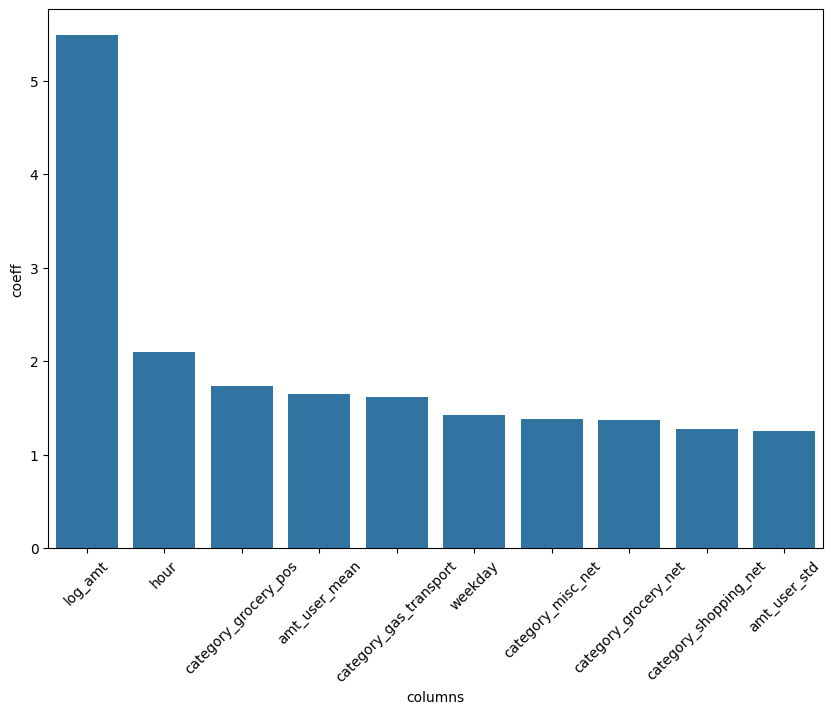

In [7]:
plt.figure(figsize=(10,7))
sns.barplot(data=df_coeff.head(10),x="columns",y="coeff")
plt.xticks(rotation = 45)
plt.show()

In [8]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add constant (intercept) to the dataset
x_train_const = add_constant(x_train)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = x_train_const.columns
vif_data["VIF"] = [variance_inflation_factor(x_train_const.values, i) for i in range(x_train_const.shape[1])]

print(vif_data)

d:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\venv\Lib\site-packages\statsmodels\regression\linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


          feature        VIF
0           const   1.000000
1             amt   4.197340
2        city_pop   1.256053
3         log_amt   2.512709
4   amt_user_mean   1.358405
..            ...        ...
78       state_WA   9.333465
79       state_WI  12.859790
80       state_WV  13.435180
81       state_WY   9.143788
82    txn_last_1h   4.642015

[83 rows x 2 columns]


In [ ]:
# !pip install shap 

   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ------------------ --------------------- 262.1/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 407.4 kB/s  0:00:01
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/38.1 MB ? eta -:--:--
    --------------------------------------- 0.5/38.1 MB 2.3 MB/s eta 0:00:17
   - -------------------------------------- 1.3/38.1 MB 2.1 MB/s eta 0:00:18
   - -------------------------------------- 1.6/38.1 MB 


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


d:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


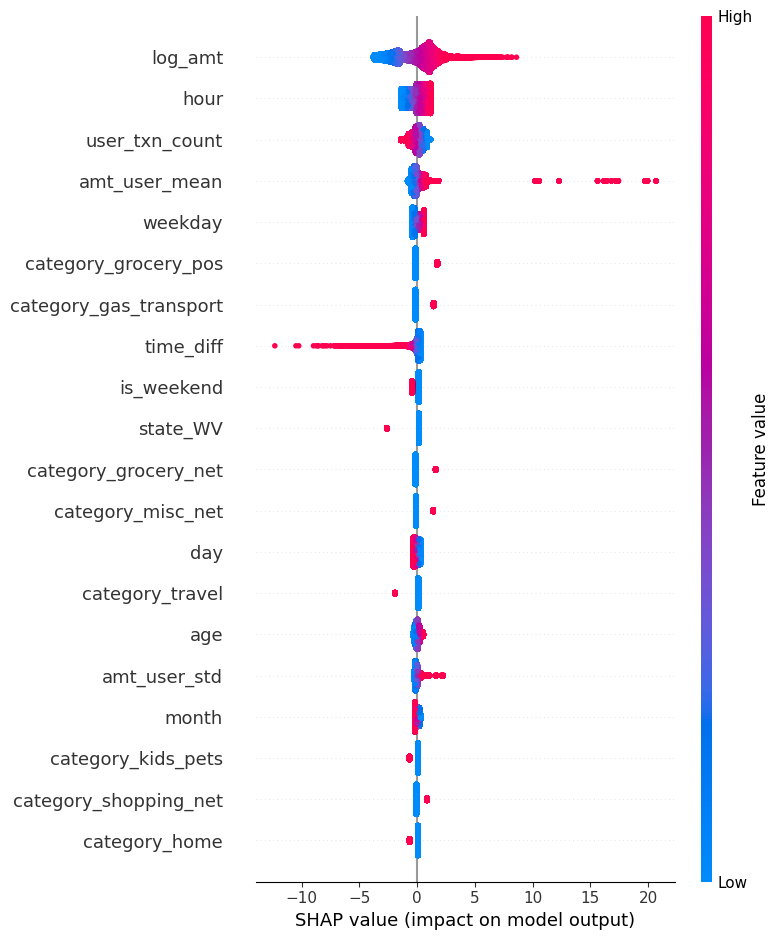

In [9]:
import shap

explainer = shap.Explainer(model_log, x_train)
shap_values = explainer(x_train)

shap.summary_plot(shap_values, x_train)

### Fitting models with default args

d:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)




Confusion Matrix : 
 [[110707     97]
 [   284     56]]


Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110804
           1       0.37      0.16      0.23       340

    accuracy                           1.00    111144
   macro avg       0.68      0.58      0.61    111144
weighted avg       1.00      1.00      1.00    111144



Cohen-Kappa Score : 0.2257103462076543
F1 Score : 0.22718052738336714
Accuracy : 0.9965720146836536
Recall : 0.16470588235294117




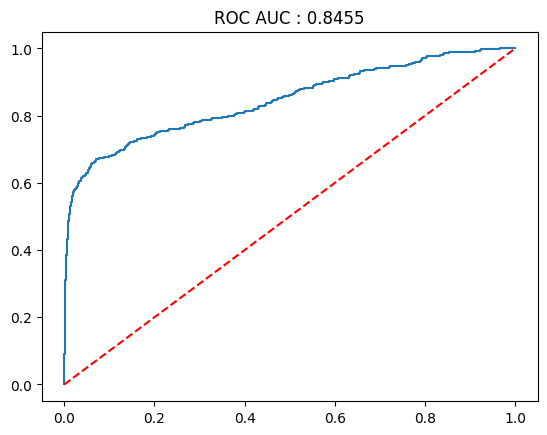

,Model,Accuracy,Recall,Precision,F1_Score,Cohen_Kappa_Score
0,LogisticRegression(),0.9966,0.1647,0.366,0.2272,0.2257


In [10]:
classification_model_scores(LogisticRegression(),x_train,y_train,x_test,y_test)

d:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)




Confusion Matrix : 
 [[14512 96292]
 [   13   327]]


Classification Report : 
               precision    recall  f1-score   support

           0       1.00      0.13      0.23    110804
           1       0.00      0.96      0.01       340

    accuracy                           0.13    111144
   macro avg       0.50      0.55      0.12    111144
weighted avg       1.00      0.13      0.23    111144



Cohen-Kappa Score : 0.0006523615974277641
F1 Score : 0.006745119070947514
Accuracy : 0.1335114806017419
Recall : 0.961764705882353




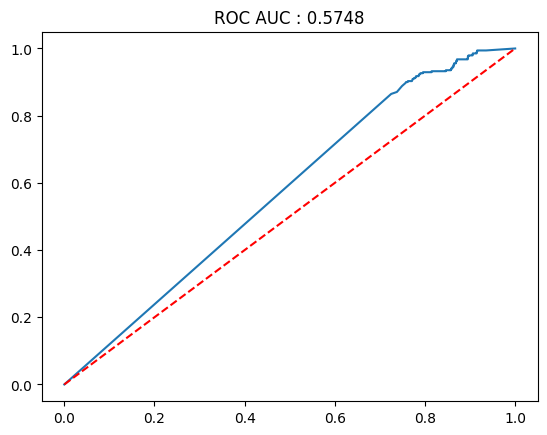

,Model,Accuracy,Recall,Precision,F1_Score,Cohen_Kappa_Score
0,LogisticRegression(),0.9966,0.1647,0.3660,0.2272,0.2257
1,GaussianNB(),0.1335,0.9618,0.0034,0.0067,0.0007


In [11]:
classification_model_scores(GaussianNB(),x_train,y_train,x_test,y_test)

d:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\venv\Lib\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)




Confusion Matrix : 
 [[110743     61]
 [   273     67]]


Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110804
           1       0.52      0.20      0.29       340

    accuracy                           1.00    111144
   macro avg       0.76      0.60      0.64    111144
weighted avg       1.00      1.00      1.00    111144



Cohen-Kappa Score : 0.2851285555913655
F1 Score : 0.2863247863247863
Accuracy : 0.9969948895127042
Recall : 0.19705882352941176




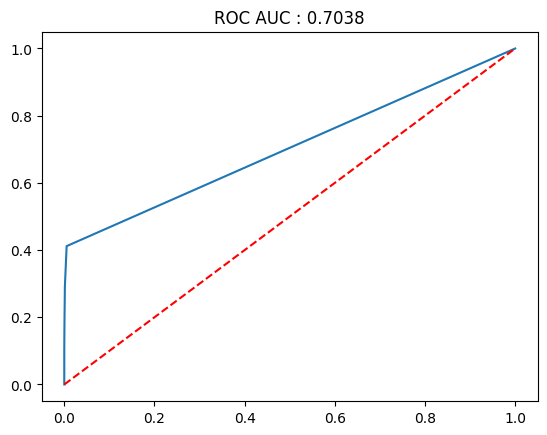

,Model,Accuracy,Recall,Precision,F1_Score,Cohen_Kappa_Score
0,LogisticRegression(),0.9966,0.1647,0.3660,0.2272,0.2257
1,GaussianNB(),0.1335,0.9618,0.0034,0.0067,0.0007
2,KNeighborsClassifier(),0.9970,0.1971,0.5234,0.2863,0.2851


In [12]:
classification_model_scores(KNeighborsClassifier(),x_train,y_train,x_test,y_test)



Confusion Matrix : 
 [[110634    170]
 [   128    212]]


Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110804
           1       0.55      0.62      0.59       340

    accuracy                           1.00    111144
   macro avg       0.78      0.81      0.79    111144
weighted avg       1.00      1.00      1.00    111144



Cohen-Kappa Score : 0.5859172121273708
F1 Score : 0.5872576177285319
Accuracy : 0.9973187936370834
Recall : 0.6235294117647059




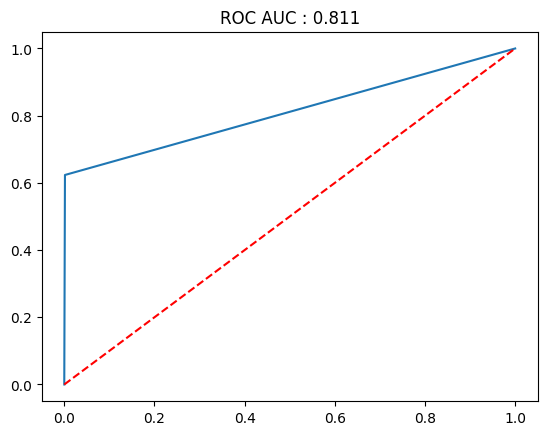

,Model,Accuracy,Recall,Precision,F1_Score,Cohen_Kappa_Score
0,LogisticRegression(),0.9966,0.1647,0.3660,0.2272,0.2257
1,GaussianNB(),0.1335,0.9618,0.0034,0.0067,0.0007
2,KNeighborsClassifier(),0.9970,0.1971,0.5234,0.2863,0.2851
3,DecisionTreeClassifier(),0.9973,0.6235,0.5550,0.5873,0.5859


In [13]:
classification_model_scores(DecisionTreeClassifier(),x_train,y_train,x_test,y_test)

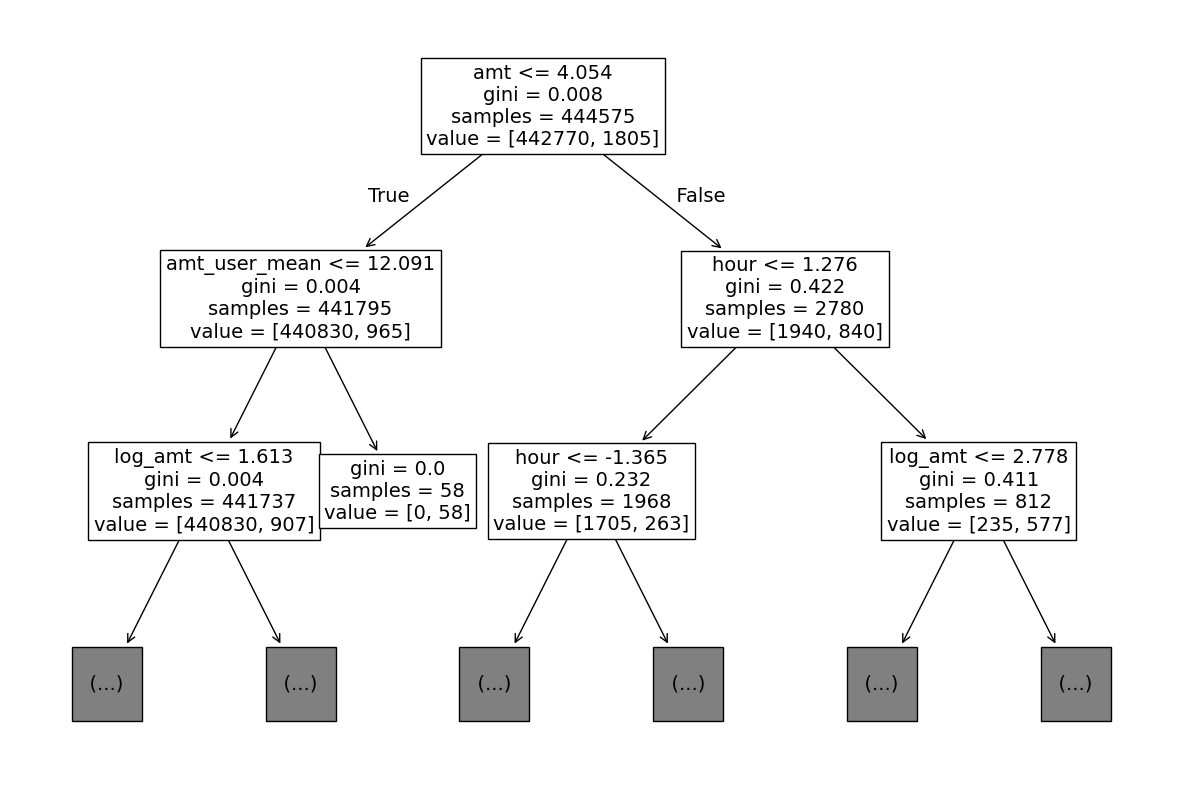

In [25]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15,10))
plot_tree(DecisionTreeClassifier().fit(x_train,y_train),max_depth=2,
          fontsize=14,
          feature_names=x_train.columns)
plt.show()

d:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)




Confusion Matrix : 
 [[110791     13]
 [   169    171]]


Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110804
           1       0.93      0.50      0.65       340

    accuracy                           1.00    111144
   macro avg       0.96      0.75      0.83    111144
weighted avg       1.00      1.00      1.00    111144



Cohen-Kappa Score : 0.6519239590038506
F1 Score : 0.6526717557251909
Accuracy : 0.9983624847045275
Recall : 0.5029411764705882




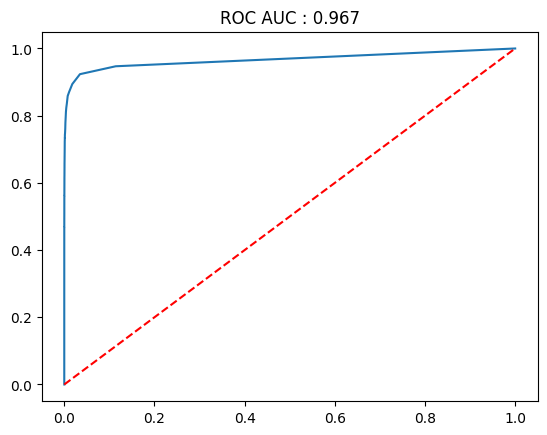

,Model,Accuracy,Recall,Precision,F1_Score,Cohen_Kappa_Score
0,LogisticRegression(),0.9966,0.1647,0.3660,0.2272,0.2257
1,GaussianNB(),0.1335,0.9618,0.0034,0.0067,0.0007
2,KNeighborsClassifier(),0.9970,0.1971,0.5234,0.2863,0.2851
3,DecisionTreeClassifier(),0.9973,0.6235,0.5550,0.5873,0.5859
4,RandomForestClassifier(),0.9984,0.5029,0.9293,0.6527,0.6519


In [26]:
classification_model_scores(RandomForestClassifier(),x_train,y_train,x_test,y_test)



Confusion Matrix : 
 [[110769     35]
 [   147    193]]


Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110804
           1       0.85      0.57      0.68       340

    accuracy                           1.00    111144
   macro avg       0.92      0.78      0.84    111144
weighted avg       1.00      1.00      1.00    111144



Cohen-Kappa Score : 0.6787886040424582
F1 Score : 0.6795774647887324
Accuracy : 0.9983624847045275
Recall : 0.5676470588235294




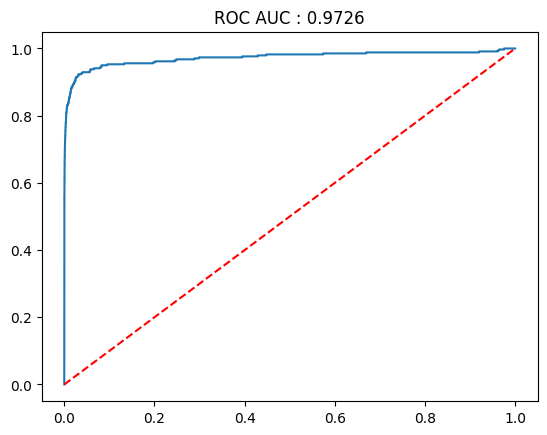

,Model,Accuracy,Recall,Precision,F1_Score,Cohen_Kappa_Score
0,LogisticRegression(),0.9966,0.1647,0.3660,0.2272,0.2257
1,GaussianNB(),0.1335,0.9618,0.0034,0.0067,0.0007
2,KNeighborsClassifier(),0.9970,0.1971,0.5234,0.2863,0.2851
3,DecisionTreeClassifier(),0.9973,0.6235,0.5550,0.5873,0.5859
4,RandomForestClassifier(),0.9984,0.5029,0.9293,0.6527,0.6519
5,"XGBClassifier(base_score=None, booster=None, c...",0.9984,0.5676,0.8465,0.6796,0.6788


In [29]:
classification_model_scores(XGBClassifier(),x_train,y_train,x_test,y_test)

d:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\venv\Lib\site-packages\sklearn\preprocessing\_label.py:103: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
d:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\venv\Lib\site-packages\sklearn\preprocessing\_label.py:139: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Info] Number of positive: 1805, number of negative: 442770
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055368 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3373
[LightGBM] [Info] Number of data points in the train set: 444575, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.004060 -> initscore=-5.502490
[LightGBM] [Info] Start training from score -5.502490


Confusion Matrix : 
 [[110226    578]
 [   141    199]]


Classification Report : 
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    110804
           1       0.26      0.59      0.36       340

    accuracy                           0.99    111144
   macro avg       0.63      0.79      0.68    111144
weighted avg       1.00      0.99      0.99    111144



Cohen-Kappa Score : 0.3535

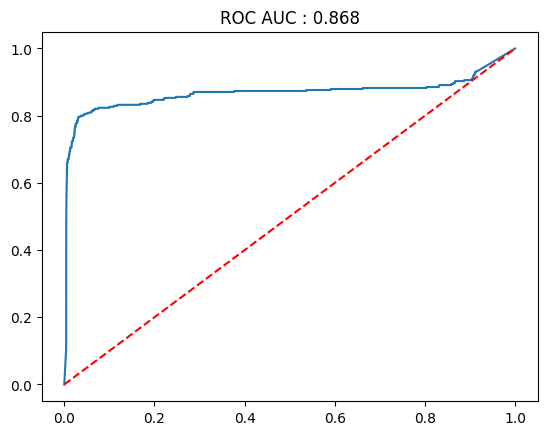

,Model,Accuracy,Recall,Precision,F1_Score,Cohen_Kappa_Score
0,LogisticRegression(),0.9966,0.1647,0.3660,0.2272,0.2257
1,GaussianNB(),0.1335,0.9618,0.0034,0.0067,0.0007
2,KNeighborsClassifier(),0.9970,0.1971,0.5234,0.2863,0.2851
3,DecisionTreeClassifier(),0.9973,0.6235,0.5550,0.5873,0.5859
4,RandomForestClassifier(),0.9984,0.5029,0.9293,0.6527,0.6519
5,"XGBClassifier(base_score=None, booster=None, c...",0.9984,0.5676,0.8465,0.6796,0.6788
6,LGBMClassifier(),0.9935,0.5853,0.2561,0.3563,0.3536


In [32]:
classification_model_scores(LGBMClassifier(),x_train,y_train,x_test,y_test)

d:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)




Confusion Matrix : 
 [[110773     31]
 [   241     99]]


Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110804
           1       0.76      0.29      0.42       340

    accuracy                           1.00    111144
   macro avg       0.88      0.65      0.71    111144
weighted avg       1.00      1.00      1.00    111144



Cohen-Kappa Score : 0.4202955822208859
F1 Score : 0.42127659574468085
Accuracy : 0.9975527243935794
Recall : 0.2911764705882353




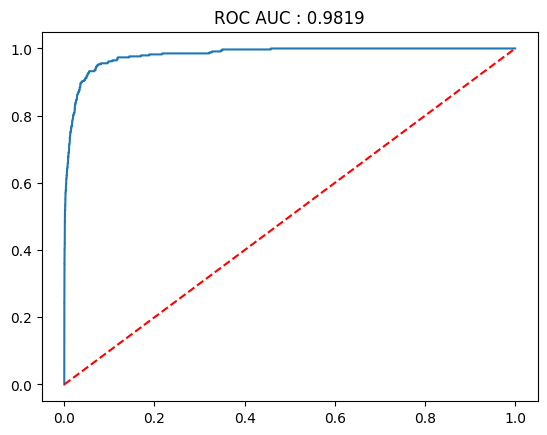

,Model,Accuracy,Recall,Precision,F1_Score,Cohen_Kappa_Score
0,LogisticRegression(),0.9966,0.1647,0.3660,0.2272,0.2257
1,GaussianNB(),0.1335,0.9618,0.0034,0.0067,0.0007
2,KNeighborsClassifier(),0.9970,0.1971,0.5234,0.2863,0.2851
3,DecisionTreeClassifier(),0.9973,0.6235,0.5550,0.5873,0.5859
4,RandomForestClassifier(),0.9984,0.5029,0.9293,0.6527,0.6519
5,"XGBClassifier(base_score=None, booster=None, c...",0.9984,0.5676,0.8465,0.6796,0.6788
6,LGBMClassifier(),0.9935,0.5853,0.2561,0.3563,0.3536
7,AdaBoostClassifier(),0.9976,0.2912,0.7615,0.4213,0.4203


In [33]:
classification_model_scores(AdaBoostClassifier(),x_train,y_train,x_test,y_test)

d:\Doccuments\GitHub\End-to-End-MLOps-Pipeline\venv\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)




Confusion Matrix : 
 [[110720     84]
 [   191    149]]


Classification Report : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110804
           1       0.64      0.44      0.52       340

    accuracy                           1.00    111144
   macro avg       0.82      0.72      0.76    111144
weighted avg       1.00      1.00      1.00    111144



Cohen-Kappa Score : 0.5188728358202941
F1 Score : 0.5200698080279232
Accuracy : 0.9975257323832145
Recall : 0.43823529411764706




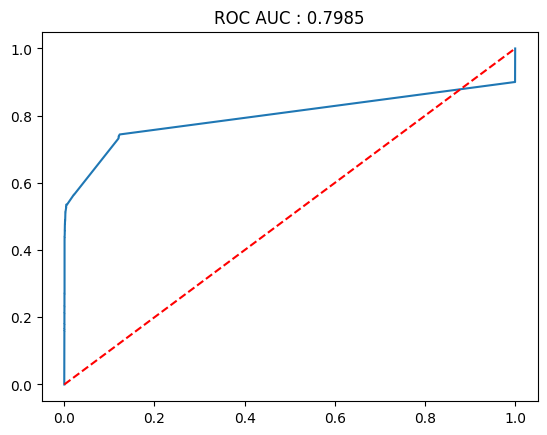

,Model,Accuracy,Recall,Precision,F1_Score,Cohen_Kappa_Score
0,LogisticRegression(),0.9966,0.1647,0.3660,0.2272,0.2257
1,GaussianNB(),0.1335,0.9618,0.0034,0.0067,0.0007
2,KNeighborsClassifier(),0.9970,0.1971,0.5234,0.2863,0.2851
3,DecisionTreeClassifier(),0.9973,0.6235,0.5550,0.5873,0.5859
4,RandomForestClassifier(),0.9984,0.5029,0.9293,0.6527,0.6519
5,"XGBClassifier(base_score=None, booster=None, c...",0.9984,0.5676,0.8465,0.6796,0.6788
6,LGBMClassifier(),0.9935,0.5853,0.2561,0.3563,0.3536
7,AdaBoostClassifier(),0.9976,0.2912,0.7615,0.4213,0.4203
8,GradientBoostingClassifier(),0.9975,0.4382,0.6395,0.5201,0.5189


In [34]:
classification_model_scores(GradientBoostingClassifier(),x_train,y_train,x_test,y_test)

In [59]:
score_card=score_card.sort_values(by="Recall",ascending=False)

In [60]:
score_card.shape

(9, 6)

In [65]:
score_card["Model"].to_list()

['GaussianNB()',
 'DecisionTreeClassifier()',
 'LGBMClassifier()',
 'XGBClassifier(base_score=None, booster=None, callbacks=None,\n              colsample_bylevel=None, colsample_bynode=None,\n              colsample_bytree=None, device=None, early_stopping_rounds=None,\n              enable_categorical=False, eval_metric=None, feature_types=None,\n              feature_weights=None, gamma=None, grow_policy=None,\n              importance_type=None, interaction_constraints=None,\n              learning_rate=None, max_bin=None, max_cat_threshold=None,\n              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,\n              max_leaves=None, min_child_weight=None, missing=nan,\n              monotone_constraints=None, multi_strategy=None, n_estimators=None,\n              n_jobs=None, num_parallel_tree=None, ...)',
 'RandomForestClassifier()',
 'GradientBoostingClassifier()',
 'AdaBoostClassifier()',
 'KNeighborsClassifier()',
 'LogisticRegression()']

In [66]:
x_tics_values = [score_card["Model"].to_list()[i].split("(")[0] for i in range(score_card.shape[0])]

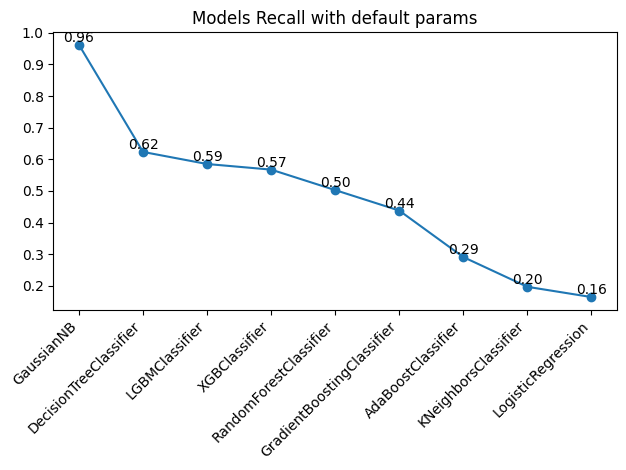

In [76]:
plt.title("Models Recall with default params")
plt.plot(x_tics_values, score_card["Recall"], marker='o')

for i, val in enumerate(score_card["Recall"]):
    plt.text(i, val, f"{val:.2f}", ha='center', va='bottom')

plt.xticks(range(len(x_tics_values)), x_tics_values, rotation=45, ha='right')
plt.tight_layout()

### Models with 